In [54]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


# **Amazon Sales Data — Cleaning & Analysis**


**Dataset Overview**

**Rows**: 42,675 (before removing duplicates)


**Columns**: 16 original columns


**Fully duplicated rows found**: 962


**General issue**: every column was stored as text (object/str), even numeric fields like price, rating, and review counts.

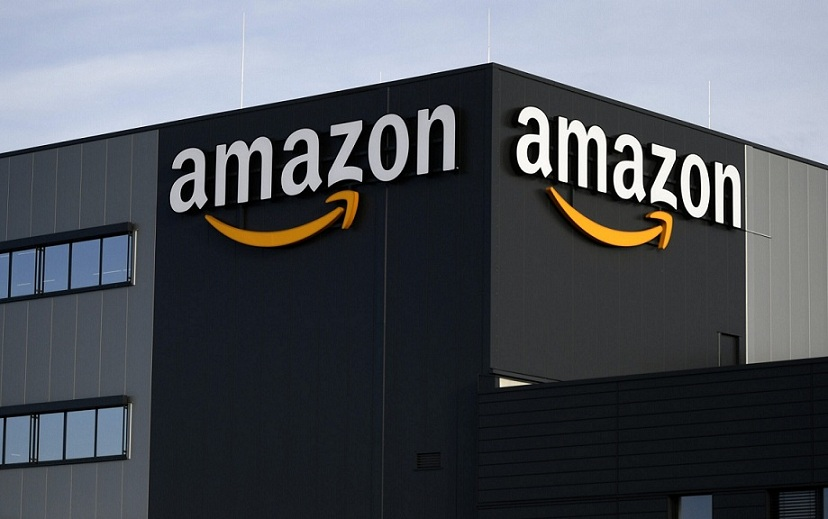

In [55]:
from IPython.display import Image, display

display(Image(r"D:\My Data Analysis Projects\Amazon Sales Project\amazon.jpg"))

**Purpose**: understand the scale of the problem before fixing anything — how many missing values per column, how many duplicate rows, and the current (incorrect) data type of every column.

In [56]:
df=pd.read_csv(r"D:\My Data Analysis Projects\Data Sets\amazon_sales_data_uncleaned.csv")

In [57]:
df

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,21-08-2025 11:14
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,21-08-2025 11:14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0 out of 5 stars,1,100+ bought in past month,195.99,basic variant price: nan,No Discount,No Badge,Organic,No Coupon,NaN,"FREE delivery Thu, Sep 4Or fastest delivery Tu...",NaN,https://m.media-amazon.com/images/I/51KCB+egEs...,/Elgato-4K-Pro-Internal-Capture/dp/B0DLR3WQWR/...,30-08-2025 19:56
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2 out of 5 stars,20,200+ bought in past month,89.99,basic variant price: $25.00 off coupon applied,No Discount,No Badge,Organic,Save $25.00 with coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery Mo...",NaN,https://m.media-amazon.com/images/I/51jV+o1LZE...,/Arlo-Essential-Spotlight-Camera-Surveillance/...,30-08-2025 19:56
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3 out of 5 stars,57,50+ bought in past month,899.99,basic variant price: Lowest price in 30 days,"$1,099.99",Save 18%,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,/GIGABYTE-FO32U2-32-3840x2160-240Hz-FreeSync-A...,30-08-2025 19:56
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7 out of 5 stars,"7,102",500+ bought in past month,10.39,basic variant price: nan,$15.98,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4 on $35 of items shipp...",NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,/Monoprice-XLR-Male-4-Inch-Cable/dp/B001UJEKZ6...,30-08-2025 19:56


**Examination of preliminary data**

In [58]:
df.shape

(42675, 16)

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Title                     42675 non-null  str  
 1   Rating                    41651 non-null  str  
 2   Number_of_reviews         41651 non-null  str  
 3   bought_in_last_month      39458 non-null  str  
 4   Current/discounted_price  30926 non-null  str  
 5   Price_on_variant          42675 non-null  str  
 6   Listed_price              42675 non-null  str  
 7   is_best_seller            42675 non-null  str  
 8   is_sponsored              42675 non-null  str  
 9   is_couponed               42675 non-null  str  
 10  buy_box_availability      28022 non-null  str  
 11  delivery_details          30955 non-null  str  
 12  sustainability_badges     3408 non-null   str  
 13  image_url                 42675 non-null  str  
 14  product_url               40606 non-null  str  
 

In [60]:
df.head()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,21-08-2025 11:14
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,21-08-2025 11:14


In [61]:
df.tail()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0 out of 5 stars,1,100+ bought in past month,195.99,basic variant price: nan,No Discount,No Badge,Organic,No Coupon,NaN,"FREE delivery Thu, Sep 4Or fastest delivery Tu...",NaN,https://m.media-amazon.com/images/I/51KCB+egEs...,/Elgato-4K-Pro-Internal-Capture/dp/B0DLR3WQWR/...,30-08-2025 19:56
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2 out of 5 stars,20,200+ bought in past month,89.99,basic variant price: $25.00 off coupon applied,No Discount,No Badge,Organic,Save $25.00 with coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery Mo...",NaN,https://m.media-amazon.com/images/I/51jV+o1LZE...,/Arlo-Essential-Spotlight-Camera-Surveillance/...,30-08-2025 19:56
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3 out of 5 stars,57,50+ bought in past month,899.99,basic variant price: Lowest price in 30 days,"$1,099.99",Save 18%,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,/GIGABYTE-FO32U2-32-3840x2160-240Hz-FreeSync-A...,30-08-2025 19:56
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7 out of 5 stars,"7,102",500+ bought in past month,10.39,basic variant price: nan,$15.98,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4 on $35 of items shipp...",NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,/Monoprice-XLR-Male-4-Inch-Cable/dp/B001UJEKZ6...,30-08-2025 19:56
42674,Lorex Fusion 1080p HD Security Camera System w...,4.4 out of 5 stars,75,50+ bought in past month,419.99,basic variant price: nan,$499.99,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",NaN,https://m.media-amazon.com/images/I/71wTn+zoSr...,/Lorex-8-Channel-Security-Outdoor-Cameras/dp/B...,30-08-2025 19:56


**Data Cleaning**

In [62]:
df.isna().sum()

Title                           0
Rating                       1024
Number_of_reviews            1024
bought_in_last_month         3217
Current/discounted_price    11749
Price_on_variant                0
Listed_price                    0
is_best_seller                  0
is_sponsored                    0
is_couponed                     0
buy_box_availability        14653
delivery_details            11720
sustainability_badges       39267
image_url                       0
product_url                  2069
collected_at                    0
dtype: int64

In [63]:
df.duplicated().sum()

np.int64(962)

**Remove Duplicate Rows**

In [64]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

Removes the 962 fully duplicated rows.

**Cleaning Rating Column**

In [65]:
df["Rating"].unique()

<StringArray>
['4.6 out of 5 stars', '4.3 out of 5 stars', '4.8 out of 5 stars',
 '4.5 out of 5 stars', '4.0 out of 5 stars', '4.7 out of 5 stars',
 '4.2 out of 5 stars', '4.4 out of 5 stars', '4.1 out of 5 stars',
 '4.9 out of 5 stars', '3.9 out of 5 stars', '3.8 out of 5 stars',
 '2.8 out of 5 stars', '3.6 out of 5 stars', '3.7 out of 5 stars',
 '3.4 out of 5 stars', '3.5 out of 5 stars',                  nan,
 '5.0 out of 5 stars', '3.3 out of 5 stars', '2.4 out of 5 stars',
 '2.9 out of 5 stars', '3.2 out of 5 stars', '3.0 out of 5 stars',
 '1.0 out of 5 stars', '2.3 out of 5 stars', '3.1 out of 5 stars',
 '2.5 out of 5 stars', '2.7 out of 5 stars', '1.5 out of 5 stars',
 '2.6 out of 5 stars', '2.0 out of 5 stars']
Length: 32, dtype: str

Original format: "4.6 out of 5 stars" (text), with ~1024 missing values.

In [66]:
df['Rating'] = df['Rating'].str.extract(r'(\d+\.\d+)').astype(float)
df['Rating'].dtype

dtype('float64')

**Decision on missing values**: left as NaN intentionally — not dropped, not imputed. Pandas automatically excludes NaN from statistical operations (mean, median, plots)

In [67]:
df['Rating'].head()


0    4.6
1    4.3
2    4.6
3    4.6
4    4.8
Name: Rating, dtype: float64

In [68]:
df

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,21-08-2025 11:14
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,21-08-2025 11:14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1,100+ bought in past month,195.99,basic variant price: nan,No Discount,No Badge,Organic,No Coupon,NaN,"FREE delivery Thu, Sep 4Or fastest delivery Tu...",NaN,https://m.media-amazon.com/images/I/51KCB+egEs...,/Elgato-4K-Pro-Internal-Capture/dp/B0DLR3WQWR/...,30-08-2025 19:56
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20,200+ bought in past month,89.99,basic variant price: $25.00 off coupon applied,No Discount,No Badge,Organic,Save $25.00 with coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery Mo...",NaN,https://m.media-amazon.com/images/I/51jV+o1LZE...,/Arlo-Essential-Spotlight-Camera-Surveillance/...,30-08-2025 19:56
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57,50+ bought in past month,899.99,basic variant price: Lowest price in 30 days,"$1,099.99",Save 18%,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,/GIGABYTE-FO32U2-32-3840x2160-240Hz-FreeSync-A...,30-08-2025 19:56
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,"7,102",500+ bought in past month,10.39,basic variant price: nan,$15.98,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Thu, Sep 4 on $35 of items shipp...",NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,/Monoprice-XLR-Male-4-Inch-Cable/dp/B001UJEKZ6...,30-08-2025 19:56


**Cleaning Number_of_reviews Column**

In [69]:
df["Number_of_reviews"].unique()

<StringArray>
[     '375',    '2,457',    '3,044',   '35,882',   '28,988',   '44,522',
   '13,466',   '38,105',    '4,380',    '7,308',
 ...
    '1,778',   '25,076',   '24,138',    '7,102',   '23,051',    '4,874',
 '1,19,218', '1,37,630',   '17,060',    '1,589']
Length: 4414, dtype: str

Original format: "2,457" (text with thousands separator).

In [70]:
df['Number_of_reviews'] = df['Number_of_reviews'].astype(str).str.replace(' ', '').str.replace(',', '')
df['Number_of_reviews'] = df['Number_of_reviews'].astype(float)

Removes stray spaces and thousands-separator commas


Converts the cleaned text to float

In [71]:
df["Number_of_reviews"].head()

0      375.0
1     2457.0
2     3044.0
3    35882.0
4    28988.0
Name: Number_of_reviews, dtype: float64

In [72]:
df['Number_of_reviews'].dtype


dtype('float64')

In [73]:
df['Number_of_reviews'].isnull().sum()

np.int64(1024)

In [74]:
df[df['Rating'].isnull() & df['Number_of_reviews'].isnull()].shape

(1024, 16)

**Cleaning bought_in_last_month Column**

In [75]:
df['bought_in_last_month']

0        300+ bought in past month
1         6K+ bought in past month
2         2K+ bought in past month
3        10K+ bought in past month
4        10K+ bought in past month
                   ...            
42670    100+ bought in past month
42671    200+ bought in past month
42672     50+ bought in past month
42673    500+ bought in past month
42674     50+ bought in past month
Name: bought_in_last_month, Length: 41713, dtype: str

Original format: "300+ bought in past month", "6K+ bought in past month", etc.

In [ ]:
# Step 1: extract the numeric part and the optional 'K' suffix

df[['num_part', 'k_part']] = df['bought_in_last_month'].str.extract(r'(\d+)(K)?\+')

In [94]:
df[['num_part', 'k_part']].head(10)

,num_part,k_part
0,300,NaN
1,6,K
2,2,K
3,10,K
4,10,K
5,100,K
6,10,K
7,10,K
8,NaN,NaN
9,10,K


In [95]:
df.columns

Index(['Title', 'Rating', 'Number_of_reviews', 'bought_in_last_month',
       'Current/discounted_price', 'Price_on_variant', 'Listed_price',
       'is_best_seller', 'is_sponsored', 'is_couponed', 'buy_box_availability',
       'delivery_details', 'sustainability_badges', 'image_url', 'product_url',
       'collected_at', 'num_part', 'k_part', 'bought_last_month_num'],
      dtype='str')

In [96]:
df.head()

,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at,num_part,k_part,bought_last_month_num
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14,300,NaN,300.0
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14,6,K,6000.0
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,21-08-2025 11:14,2,K,2000.0
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,21-08-2025 11:14,10,K,10000.0
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,21-08-2025 11:14,10,K,10000.0


In [ ]:
# Step 1: extract the numeric part and the optional 'K' suffix

df['num_part'] = df['num_part'].astype(float)

# Step 3: multiply by 1000 where 'K' is present, otherwise keep as-is

df['bought_last_month_num'] = np.where(df['k_part'] == 'K', df['num_part'] * 1000, df['num_part'])

In [98]:
df[['bought_in_last_month', 'num_part', 'k_part', 'bought_last_month_num']].head(10)

,bought_in_last_month,num_part,k_part,bought_last_month_num
0,300+ bought in past month,300.0,NaN,300.0
1,6K+ bought in past month,6.0,K,6000.0
2,2K+ bought in past month,2.0,K,2000.0
3,10K+ bought in past month,10.0,K,10000.0
4,10K+ bought in past month,10.0,K,10000.0
5,100K+ bought in past month,100.0,K,100000.0
6,10K+ bought in past month,10.0,K,10000.0
7,10K+ bought in past month,10.0,K,10000.0
8,NaN,NaN,NaN,NaN
9,10K+ bought in past month,10.0,K,10000.0


In [ ]:
# Step 4: drop the temporary helper columns

df = df.drop(columns=['num_part', 'k_part'])

In [100]:
df.columns

Index(['Title', 'Rating', 'Number_of_reviews', 'bought_in_last_month',
       'Current/discounted_price', 'Price_on_variant', 'Listed_price',
       'is_best_seller', 'is_sponsored', 'is_couponed', 'buy_box_availability',
       'delivery_details', 'sustainability_badges', 'image_url', 'product_url',
       'collected_at', 'bought_last_month_num'],
      dtype='str')

**Cleaning Current/discounted_price Column**

In [101]:
df['Current/discounted_price'].unique()[:10]


<StringArray>
[ '89.68',   '9.99',    '314',      nan,  '16.99',  '14.99',  '29.99',
 '249.99',  '69.95',  '39.97']
Length: 10, dtype: str

Original format: plain numbers as text, some with thousands separators (e.g. '1,699.99').

In [104]:
df['Current/discounted_price'] = df['Current/discounted_price'].astype(str).str.replace(',', '').astype('float')


In [106]:
df['Current/discounted_price'].dtype


dtype('float64')

In [ ]:
df['Current/discounted_price'].isnull().sum()

np.int64(11588)

**Cleaning Price_on_variant Column**

In [107]:
df['Price_on_variant'].unique()[:15]

<StringArray>
[ 'basic variant price: 2.4GHz',     'basic variant price: nan',
 'basic variant price: $162.24',  'basic variant price: $72.74',
  'basic variant price: $99.95',  'basic variant price: $88.11',
  'basic variant price: $23.04', 'basic variant price: $284.05',
 'basic variant price: $880.95',  'basic variant price: $17.45',
  'basic variant price: $38.86',  'basic variant price: $13.88',
  'basic variant price: $33.51',  'basic variant price: $16.78',
 'basic variant price: $146.14']
Length: 15, dtype: str

Original format: "basic variant price: $162.24", "basic variant price: nan", or garbage values like "basic variant price: 2.4GHz".

In [108]:
df['Price_on_variant'] = df['Price_on_variant'].str.extract(r'\$([\d.]+)').astype(float)

In [109]:
df['Price_on_variant'].dtype


dtype('float64')

In [110]:
df['Price_on_variant'].isnull().sum()


np.int64(21802)

In [111]:
df['Price_on_variant'].head(10)

0       NaN
1       NaN
2       NaN
3    162.24
4     72.74
5     99.95
6     88.11
7     23.04
8       NaN
9    284.05
Name: Price_on_variant, dtype: float64

**Cleaning Listed_price Column**

In [112]:
df['Listed_price'].unique()[:15]

<StringArray>
[    '$159.00',      '$15.99',     '$349.00', 'No Discount',      '$19.98',
      '$14.33',      '$17.99',      '$21.89',      '$20.00',      '$48.99',
      '$19.99',      '$38.98',      '$14.39',     '$169.99',      '$29.99']
Length: 15, dtype: str

Original format: "$159.00", or the text "No Discount" 


In [ ]:
# Step 1: remove currency symbol and thousands separators

df['Listed_price'] = df['Listed_price'].str.replace('$', '', regex=False).str.replace(',', '')
df['Listed_price'].unique()

<StringArray>
[     '159.00',       '15.99',      '349.00', 'No Discount',       '19.98',
       '14.33',       '17.99',       '21.89',       '20.00',       '48.99',
 ...
     '2899.00',       '16.97',     '2999.99',        '9.10',     '1749.99',
       '21.39',      '599.95',      '139.98',      '149.98',      '950.43']
Length: 911, dtype: str

In [ ]:
# Step 2: convert to numeric, forcing non-numeric text (e.g. "No Discount") to NaN

df['Listed_price'] = pd.to_numeric(df['Listed_price'], errors='coerce')

In [121]:
df['Listed_price'] = df['Listed_price'].astype(float)


In [ ]:
# Step 3: fill "No Discount" rows (now NaN) with the current price 
# meaning "no discount" = listed price equals the current price

df['Listed_price'] = df['Listed_price'].fillna(df['Current/discounted_price'])

In [124]:
df[['Current/discounted_price', 'Price_on_variant', 'Listed_price']].dtypes


Current/discounted_price    float64
Price_on_variant            float64
Listed_price                float64
dtype: object

In [125]:
df['Listed_price'].isnull().sum()

np.int64(11588)

Why pd.to_numeric(..., errors='coerce') instead of .astype(float): astype(float) raises an error on non-numeric text; pd.to_numeric with errors='coerce' converts anything non-numeric to NaN instead of crashing.


Design decision: "No Discount" is filled with Current/discounted_price (not dropped or left NaN), because that's the true meaning of "no discount" — listed price equals current price. This makes any later discount_percentage calculation correctly show 0% instead of NaN.

**Cleaning is_best_seller Column**

In [126]:
df['is_best_seller'].unique()

<StringArray>
[         'No Badge',       'Best Seller',          'Amazon's',
 'Limited time deal',          'Save 30%',          'Save 12%',
           'Save 9%',          'Save 17%',          'Save 77%',
           'Ends in',          'Save 10%',          'Save 18%']
Length: 12, dtype: str

Break down is_best_seller into multiple flags

Original column mixed several unrelated badge types: "No Badge", "Best Seller", "Amazon's", "Limited time deal", "Save X%", "Ends in".

In [127]:
df['is_best_seller_flag'] = df['is_best_seller'] == 'Best Seller'

In [128]:
df['has_limited_deal'] = df['is_best_seller'] == 'Limited time deal'

In [129]:
df['has_ends_in_deal'] = df['is_best_seller'] == 'Ends in'

In [130]:
df['has_amazons_choice'] = df['is_best_seller'] == "Amazon's"

In [131]:
df[['is_best_seller', 'is_best_seller_flag', 'has_amazons_choice', 'has_limited_deal', 'has_ends_in_deal']].head(15)

,is_best_seller,is_best_seller_flag,has_amazons_choice,has_limited_deal,has_ends_in_deal
0,No Badge,False,False,False,False
1,No Badge,False,False,False,False
2,No Badge,False,False,False,False
3,Best Seller,True,False,False,False
4,No Badge,False,False,False,False
5,Best Seller,True,False,False,False
6,No Badge,False,False,False,False
7,Best Seller,True,False,False,False
8,No Badge,False,False,False,False
9,Best Seller,True,False,False,False


Each boolean column isolates one specific meaning that was previously bundled together in a single messy text column.

In [132]:
df['best_seller_discount_pct'] = df['is_best_seller'].str.extract(r'Save (\d+)%').astype(float)

In [133]:
df[['is_best_seller', 'best_seller_discount_pct']].head(15)


,is_best_seller,best_seller_discount_pct
0,No Badge,NaN
1,No Badge,NaN
2,No Badge,NaN
3,Best Seller,NaN
4,No Badge,NaN
5,Best Seller,NaN
6,No Badge,NaN
7,Best Seller,NaN
8,No Badge,NaN
9,Best Seller,NaN


In [134]:
df['best_seller_discount_pct'].isnull().sum()

np.int64(41377)

**Cleaning is_couponed Column**

In [135]:
df['is_couponed'].unique()

<StringArray>
[                    'Save 15%  with coupon',
                                 'No Coupon',
                     'Save 50%  with coupon',
                  'Save $16.00  with coupon',
                  'Save $10.00  with coupon',
                     'Save 10%  with coupon',
                  'Save $20.00  with coupon',
                   'Save $4.00  with coupon',
                   'Save $0.33  with coupon',
                  'Save $18.00  with coupon',
                      'Save 5%  with coupon',
                   'Save $2.00  with coupon',
                  'Save $15.00  with coupon',
                      'Save 6%  with coupon',
                   'Save $8.00  with coupon',
                  'Save $40.00  with coupon',
                   'Save $1.50  with coupon',
                      'Save 7%  with coupon',
                     'Save 20%  with coupon',
                   'Save $1.00  with coupon',
                   'Save $5.00  with coupon',
                  'S

Step 10 — Break down is_couponed

Original column mixed percentage discounts and fixed-dollar discounts: "Save 15% with coupon", "Save $16.00 with coupon", "No Coupon".

In [ ]:
# 1) whether a coupon exists at all
df['has_coupon'] = df['is_couponed'] != 'No Coupon'
# 2) percentage-based discount
df['coupon_discount_pct'] = df['is_couponed'].str.extract(r'Save (\d+)%').astype(float)
# 3) fixed dollar-amount discount
df['coupon_discount_amount'] = df['is_couponed'].str.extract(r'Save \$([\d.]+)').astype(float)

In [139]:
df[['is_couponed', 'has_coupon', 'coupon_discount_pct', 'coupon_discount_amount']].head(15)


,is_couponed,has_coupon,coupon_discount_pct,coupon_discount_amount
0,Save 15% with coupon,True,15.0,NaN
1,No Coupon,False,NaN,NaN
2,No Coupon,False,NaN,NaN
3,No Coupon,False,NaN,NaN
4,No Coupon,False,NaN,NaN
5,No Coupon,False,NaN,NaN
6,No Coupon,False,NaN,NaN
7,No Coupon,False,NaN,NaN
8,Save 50% with coupon,True,50.0,NaN
9,No Coupon,False,NaN,NaN


In [140]:
df['coupon_discount_pct'].isnull().sum()


np.int64(40652)

In [141]:
df['coupon_discount_amount'].isnull().sum()

np.int64(40826)

**Cleaning sustainability_badges Column**

In [142]:
df['sustainability_badges'].unique()

<StringArray>
[                 'Carbon impact',                              nan,
              'Energy efficiency',        'Safer chemicals +1 more',
                 'Small Business', '1 sustainability certification',
               'Works with Alexa',        'Manufacturing practices',
             'Forestry practices',                 'Alexa Built-in',
      'Energy efficiency +3 more',             'Recycled materials',
        'Safer chemicals +2 more',      'Energy efficiency +1 more',
     'Recycled materials +3 more',     'Recycled materials +2 more',
                  'Made in Italy']
Length: 17, dtype: str

Column was ~92% empty (39,267 of 42,675 rows) with many different specific badge texts. Rather than splitting into many sparse columns, a single boolean summarizes presence/absence:


In [143]:
df['has_sustainability_badge'] = df['sustainability_badges'].notnull()

In [144]:
df[['sustainability_badges', 'has_sustainability_badge']].head(10)


,sustainability_badges,has_sustainability_badge
0,Carbon impact,True
1,NaN,False
2,NaN,False
3,NaN,False
4,NaN,False
5,NaN,False
6,NaN,False
7,NaN,False
8,NaN,False
9,Energy efficiency,True


In [145]:
df['has_sustainability_badge'].value_counts()

has_sustainability_badge
False    38305
True      3408
Name: count, dtype: int64

**Cleaning buy_box_availability Column**

Column only ever contained one non-null value ("Add to cart"), so it's converted to a simple boolean:

In [146]:
df['buy_box_availability'].value_counts(dropna=False)

buy_box_availability
Add to cart    27221
NaN            14492
Name: count, dtype: int64

In [147]:
df['is_available_to_buy'] = df['buy_box_availability'].notnull()

In [148]:
df['is_available_to_buy'].value_counts()

is_available_to_buy
True     27221
False    14492
Name: count, dtype: int64

# **Feature Engineering**

In [149]:
df['Title'].head(10)

0    BOYA BOYALINK 2 Wireless Lavalier Microphone f...
1    LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...
2    DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...
3    Apple AirPods Pro 2 Wireless Earbuds, Active N...
4    Apple AirTag 4 Pack. Keep Track of and find Yo...
5    Texas Instruments TI-84 Plus CE Color Graphing...
6    Apple AirPods 4 Wireless Earbuds, Bluetooth He...
7    Apple AirTag. Keep Track of and find Your Keys...
8    Complete Protect: One plan covers all eligible...
9    Apple iPad 11-inch: A16 chip, 11-inch Model, L...
Name: Title, dtype: str

Limitation: multi-word brand names (e.g. "Texas Instruments") are truncated to their first word only. Accepted as a reasonable simplification for a general overview.

In [150]:
df['Brand'] = df['Title'].str.split().str[0]

In [153]:
df[['Title', 'Brand']].head(10)


,Title,Brand
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,BOYA
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",LISEN
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",DJI
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",Apple
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,Apple
5,Texas Instruments TI-84 Plus CE Color Graphing...,Texas
6,"Apple AirPods 4 Wireless Earbuds, Bluetooth He...",Apple
7,Apple AirTag. Keep Track of and find Your Keys...,Apple
8,Complete Protect: One plan covers all eligible...,Complete
9,"Apple iPad 11-inch: A16 chip, 11-inch Model, L...",Apple


In [152]:
df['Brand'].value_counts().head(15)

Brand
ASURION      3062
HP           1966
Sony          964
Dell          923
Lenovo        881
Canon         788
UGREEN        694
Duracell      688
Apple         639
Energizer     593
Avery         585
ASUS          549
Pyle          544
KODAK         539
Belkin        525
Name: count, dtype: int64

**collected_at**

In [154]:
df['collected_at'].head(5)


0    21-08-2025 11:14
1    21-08-2025 11:14
2    21-08-2025 11:14
3    21-08-2025 11:14
4    21-08-2025 11:14
Name: collected_at, dtype: str

Original format: "21-08-2025 11:14" (day-month-year hour:minute, as text).

In [155]:
df['collected_at'].dtype

<StringDtype(storage='python', na_value=nan)>

Explicit format avoids ambiguity (day vs. month order) and is faster than letting pandas guess.

In [156]:
df['collected_at'] = pd.to_datetime(df['collected_at'], format='%d-%m-%Y %H:%M')

In [157]:
df['collected_at'].dtype


dtype('<M8[us]')

In [158]:
df['collected_at'].head()

0   2025-08-21 11:14:00
1   2025-08-21 11:14:00
2   2025-08-21 11:14:00
3   2025-08-21 11:14:00
4   2025-08-21 11:14:00
Name: collected_at, dtype: datetime64[us]

 # **Next Phase**: 
 
**Analysis & Visualization (Matplotlib / Seaborn)**

**Chart 1** Price Distribution (Histogram)

Goal: see how prices are distributed — mostly low-priced with a few expensive outliers (right-skewed), or balanced?

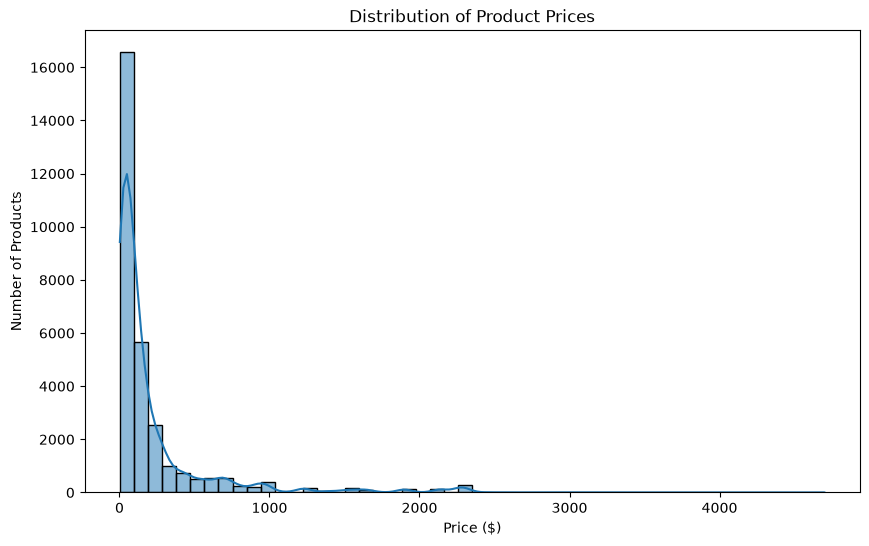

In [162]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Current/discounted_price'], bins=50, kde=True)
plt.title('Distribution of Product Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Products')
plt.show()

**Insight to look for**: if the curve is right-skewed (long tail to the right), it means most products are cheap-to-mid priced and a small number of expensive products are pulling the average up — in that case, use the median price, not the mean, when summarizing "typical" price, since the mean gets distorted by the outliers.

**Chart 2** Discount % vs. Number of Reviews (Scatter Plot)

Goal: see whether bigger discounts are associated with more customer engagement (reviews as a proxy for purchases).

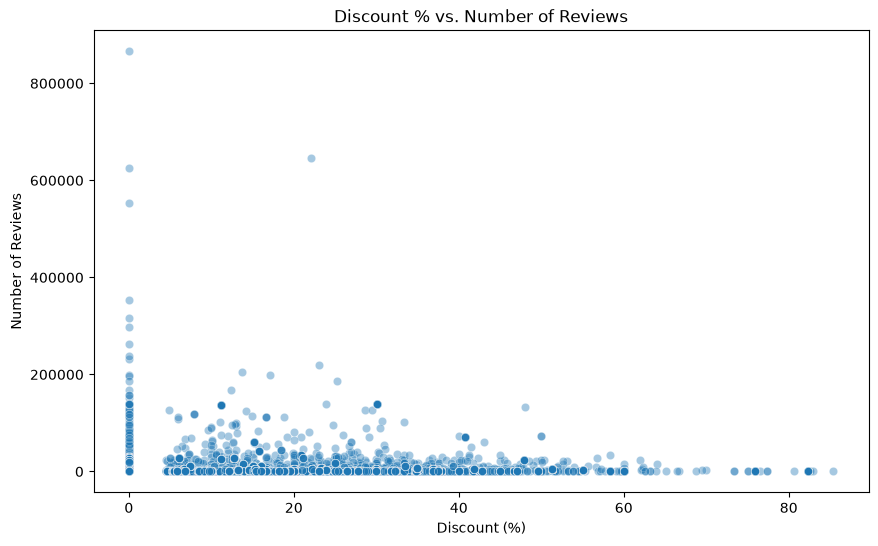

In [163]:
df['discount_percentage'] = (df['Listed_price'] - df['Current/discounted_price']) / df['Listed_price'] * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='discount_percentage', y='Number_of_reviews', alpha=0.4)
plt.title('Discount % vs. Number of Reviews')
plt.xlabel('Discount (%)')
plt.ylabel('Number of Reviews')
plt.show()

**Insight to look for**: if there's no visible pattern (points scattered randomly), it suggests review count is driven by other factors (brand, rating, ad placement) more than discount size. A slight upward trend at low-to-moderate discounts (10–30%) but a flat or declining pattern at very high discounts (>60%) often indicates that steep discounts don't necessarily mean more genuine engagement — they may signal clearance/low-demand items instead.

**Chart 3** Top 10 Brands by Estimated Sales (Bar Plot)

Goal: identify which brands dominate in estimated units sold.

C:\Users\dell\AppData\Local\Temp\ipykernel_20148\4137686861.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')


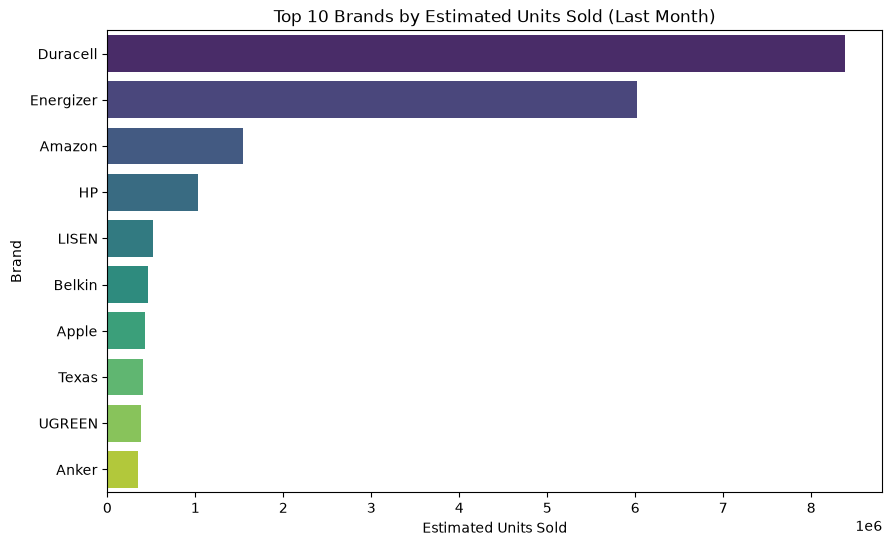

In [164]:
top_brands = df.groupby('Brand')['bought_last_month_num'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')
plt.title('Top 10 Brands by Estimated Units Sold (Last Month)')
plt.xlabel('Estimated Units Sold')
plt.ylabel('Brand')
plt.show()

**Insight to look for**: if one or two brands (e.g. Apple) massively outsell everyone else, that's a concentration insight — useful for framing a statement like "Brand X alone accounts for Y% of total estimated sales in this dataset." Worth double-checking whether that dominance holds even after excluding the top brand, to see if the rest of the market is more balanced.

**Chart 4** — Correlation Heatmap (Rating, Reviews, Price, Sales)

Goal: see which numeric variables move together — does a higher rating correlate with more sales? Does price correlate negatively with reviews?

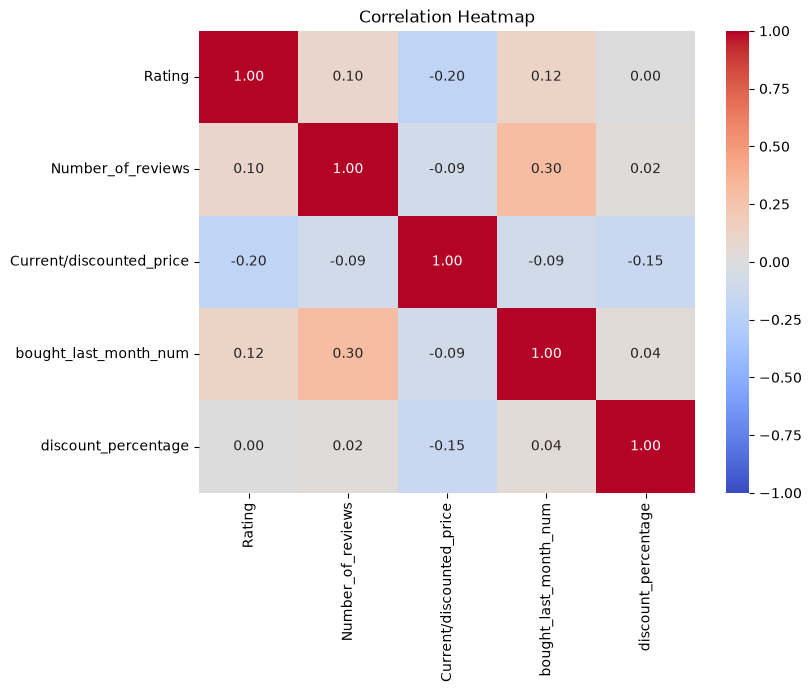

In [165]:
numeric_cols = ['Rating', 'Number_of_reviews', 'Current/discounted_price', 'bought_last_month_num', 'discount_percentage']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

**Insight to look for**: a value close to 0 between Rating and bought_last_month_num would suggest rating alone isn't a strong driver of sales volume in this dataset (other factors like brand or ads may matter more). A negative correlation between Current/discounted_price and Number_of_reviews would suggest cheaper products tend to accumulate more reviews, likely because they're bought more often.

**Chart 5**— Sponsored vs. Organic: Price and Rating Comparison (Box Plot)

Goal: see if sponsored (paid ad) listings differ systematically from organic ones in price or rating.

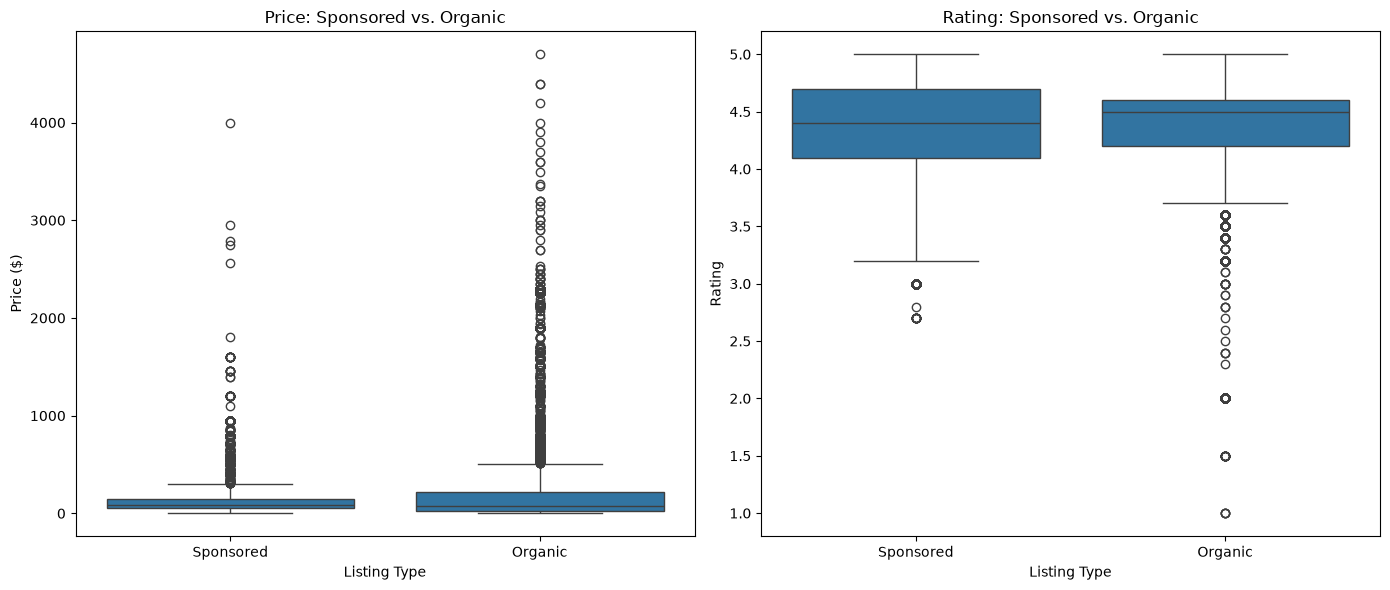

In [166]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='is_sponsored', y='Current/discounted_price', ax=axes[0])
axes[0].set_title('Price: Sponsored vs. Organic')
axes[0].set_xlabel('Listing Type')
axes[0].set_ylabel('Price ($)')

sns.boxplot(data=df, x='is_sponsored', y='Rating', ax=axes[1])
axes[1].set_title('Rating: Sponsored vs. Organic')
axes[1].set_xlabel('Listing Type')
axes[1].set_ylabel('Rating')

plt.tight_layout()
plt.show()

**Insight to look for**: if sponsored listings have a noticeably higher median price than organic ones, it may suggest sellers are more willing to pay for ads on higher-margin products. If sponsored and organic ratings look nearly identical, it means ad placement isn't correlated with product quality — it's a paid placement, not a quality signal.

**Chart 6**— Effect of Coupons on Estimated Sales (Bar Plot)

Goal: see whether having a coupon is associated with higher estimated sales volume.

C:\Users\dell\AppData\Local\Temp\ipykernel_20148\281496723.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coupon_sales.index, y=coupon_sales.values, palette='pastel')


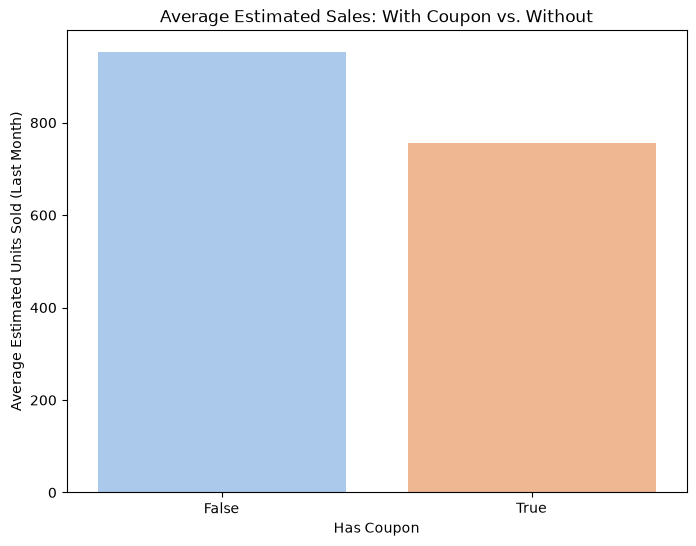

In [167]:
coupon_sales = df.groupby('has_coupon')['bought_last_month_num'].mean()

plt.figure(figsize=(8, 6))
sns.barplot(x=coupon_sales.index, y=coupon_sales.values, palette='pastel')
plt.title('Average Estimated Sales: With Coupon vs. Without')
plt.xlabel('Has Coupon')
plt.ylabel('Average Estimated Units Sold (Last Month)')
plt.show()

**Insight to look for**: if the "has coupon = True" bar is clearly taller, that supports the idea that coupons are an effective sales lever in this dataset. If the difference is small or reversed, it may mean coupons are applied more often to already slow-moving inventory (i.e. correlation isn't causation here — coupons might be a response to low sales, not a cause of high sales).